# Partie 1: Listings Airbnb Décembre 2024

## 1.Importations des bibliothéques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Importations des données et premières informations

In [2]:
df=pd.read_csv("DATA_dec_2024/listings_dec_2024.csv")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,5396,Your perfect Paris studio on Île Saint-Louis,7903,Borzou,NaN,Hôtel-de-Ville,48.85247,2.35835,Entire home/apt,88.0,3,425,2024-11-23,2.26,1,77,51,7510402838018
1,7964,Sunny apartment with balcony,22155,Anaïs,NaN,Opéra,48.87417,2.34245,Entire home/apt,NaN,7,5,2015-09-14,0.03,1,0,0,7510903576564
2,9952,Paris petit coin douillet,33534,Elisabeth,NaN,Popincourt,48.86238,2.36957,Entire home/apt,150.0,4,52,2024-09-24,0.36,1,250,3,7511101582862
3,11487,"Heart of Paris, brand new aparment.",42666,Brigitte,NaN,Popincourt,48.86351,2.37110,Entire home/apt,80.0,30,13,2024-09-27,0.09,2,246,5,"Available with a mobility lease only (""bail mo..."
4,12452,Voltaire Charm,48733,Irene,NaN,Popincourt,48.85974,2.37932,Entire home/apt,201.0,1,62,2024-10-11,0.77,1,34,4,7511102600669


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91031 entries, 0 to 91030
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              91031 non-null  int64  
 1   name                            91031 non-null  object 
 2   host_id                         91031 non-null  int64  
 3   host_name                       91022 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   91031 non-null  object 
 6   latitude                        91031 non-null  float64
 7   longitude                       91031 non-null  float64
 8   room_type                       91031 non-null  object 
 9   price                           60093 non-null  float64
 10  minimum_nights                  91031 non-null  int64  
 11  number_of_reviews               91031 non-null  int64  
 12  last_review                     

#### Toutes les colonnes ne sont pas utiles pour notre étude, nous allons les supprimer. Puis nous traiterons les valeurs manquantes . Avant cela nous allons filtrer les données pour notre étude.

In [5]:
cols_to_keep = [
    "id", "neighbourhood", "latitude", "longitude", 
    "room_type", "price", "availability_365", 
    "number_of_reviews", "reviews_per_month", "minimum_nights"]

In [6]:
df = df[cols_to_keep]

In [7]:
df.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights
0,5396,Hôtel-de-Ville,48.85247,2.35835,Entire home/apt,88.0,77,425,2.26,3
1,7964,Opéra,48.87417,2.34245,Entire home/apt,NaN,0,5,0.03,7
2,9952,Popincourt,48.86238,2.36957,Entire home/apt,150.0,250,52,0.36,4
3,11487,Popincourt,48.86351,2.37110,Entire home/apt,80.0,246,13,0.09,30
4,12452,Popincourt,48.85974,2.37932,Entire home/apt,201.0,34,62,0.77,1


## 3. Filtrages nécessaires à notre étude

In [8]:
df = df[
    (df['latitude'] >= 48.81) & (df['latitude'] <= 48.90) &
    (df['longitude'] >= 2.25) & (df['longitude'] <= 2.42)
] # Notre choix d'étude est Paris intra-muros dont on peut trouver les latitudes et longitudes correspondantes

In [9]:
df = df[df['availability_365'] > 0] # on ne garde que les logements actifs

In [10]:
df = df[
    (df['room_type'] == "Entire home/apt") &
    (df['minimum_nights'] <= 30)
]  # les logements entiers sont les plus representatifs et les plus recherchés par les touristes et ceux-ci n'effectuent pas de sejours longue durée

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52950 entries, 0 to 91030
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 52950 non-null  int64  
 1   neighbourhood      52950 non-null  object 
 2   latitude           52950 non-null  float64
 3   longitude          52950 non-null  float64
 4   room_type          52950 non-null  object 
 5   price              50869 non-null  float64
 6   availability_365   52950 non-null  int64  
 7   number_of_reviews  52950 non-null  int64  
 8   reviews_per_month  40165 non-null  float64
 9   minimum_nights     52950 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 4.4+ MB


In [12]:
df_sans_doublons=df.drop_duplicates()

In [13]:
df_sans_doublons.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52950 entries, 0 to 91030
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 52950 non-null  int64  
 1   neighbourhood      52950 non-null  object 
 2   latitude           52950 non-null  float64
 3   longitude          52950 non-null  float64
 4   room_type          52950 non-null  object 
 5   price              50869 non-null  float64
 6   availability_365   52950 non-null  int64  
 7   number_of_reviews  52950 non-null  int64  
 8   reviews_per_month  40165 non-null  float64
 9   minimum_nights     52950 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 4.4+ MB


#### Il n'y avait pas de doublons dans le dataset

## 4. Gestions des valeurs manquantes

#### La colonne 'Price' contient beaucoup de valeurs manquantes ( 2081) mais étant donné la taille du Dataset la perte de ces données est négligeable(moins de 4%) , nous allons donc supprimer ces lignes ,c'est plus simple,plus propre pour une colonne qui a son importance.

In [14]:
df = df.dropna(subset=['price'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50869 entries, 0 to 91030
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 50869 non-null  int64  
 1   neighbourhood      50869 non-null  object 
 2   latitude           50869 non-null  float64
 3   longitude          50869 non-null  float64
 4   room_type          50869 non-null  object 
 5   price              50869 non-null  float64
 6   availability_365   50869 non-null  int64  
 7   number_of_reviews  50869 non-null  int64  
 8   reviews_per_month  38627 non-null  float64
 9   minimum_nights     50869 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 4.3+ MB


#### Pour la colonne 'reviews_per_months' nous allons laisser la mention Nan qui peut prendre tout son sens surtout sil ny a jamais eu d'avis.Ou nous reviendrons plus tard sur cette décision

In [16]:
nan_reviews_per_month = df[df['reviews_per_month'].isna()]
print(nan_reviews_per_month['number_of_reviews'].value_counts())

number_of_reviews
0    12242
Name: count, dtype: int64


#### Donc en effet ces valeurs manquantes correspondent au fait qu'il n'y a aucun avis . On va donc les laisser et ajouter plus tard si besoin une colonne stipulant l'absence d'avis.

## 5. Statistiques descriptives et gestion des potentiels outliers

In [17]:
df.describe()

,id,latitude,longitude,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights
count,5.086900e+04,50869.000000,50869.000000,50869.000000,50869.000000,50869.000000,38627.000000,50869.000000
mean,7.549405e+17,48.864068,2.341578,263.861350,195.380055,26.409208,1.355295,5.438538
std,4.760464e+17,0.017693,0.034003,621.821846,119.814850,54.841416,1.377988,8.314476
min,3.109000e+03,48.816090,2.251593,7.000000,1.000000,0.000000,0.010000,1.000000
25%,5.307235e+07,48.851394,2.319390,105.000000,83.000000,1.000000,0.390000,2.000000
50%,9.628765e+17,48.865141,2.345850,152.000000,211.000000,7.000000,0.930000,3.000000
75%,1.129500e+18,48.878105,2.365267,250.000000,300.000000,27.000000,1.860000,4.000000
max,1.305100e+18,48.899880,2.416380,30400.000000,365.000000,940.000000,49.380000,30.000000


#### Dans la colonne prix par exemple la lecture du troisième quartile nous indique clairement que le maximum est une valeur aberrante.Nous allons détecter ces valeurs extrêmes dans les colonnes 'price' ,'minimum_nights'.

In [18]:
colonnes_à_traiter = ['price',  'minimum_nights']

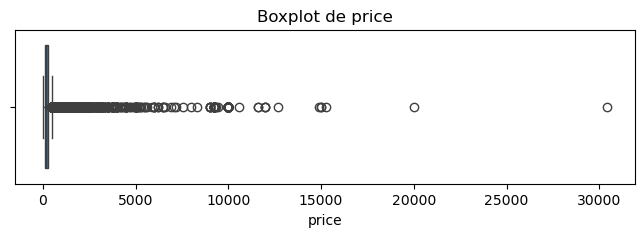

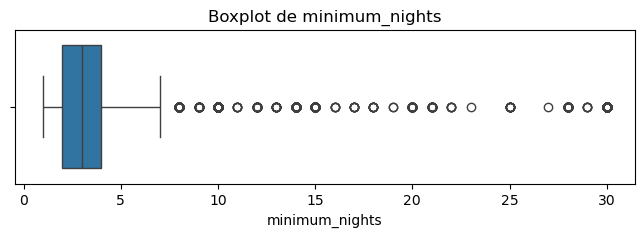

In [19]:
for col in colonnes_à_traiter:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

#### Effectivement les boxplot nous indiquent un très grand nombre de valeurs extrêmes. Il pourrait s'agir d'erreurs de saisies,de quelques logements très luxueux , très demandés ou atypiques.

In [20]:
outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns) # Un dataframe où 'False' sera remplacé par 'true' si un outlier est détecté
for col in colonnes_à_traiter :  # on  vérifie toutes les colonnes numériques sauf les colonnes binaires
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR     # calcul des quartiles et des bornes
    outlier_mask[col] = (df[col] < borne_inf) | (df[col] > borne_sup)  # le masque passera à true pour les cellules dont la valeur qui ne sont pas dans la borne
outliers = df[outlier_mask.any(axis=1)]
print("Valeurs aberrantes détectées :")
print(outliers)

Valeurs aberrantes détectées :
                        id    neighbourhood   latitude  longitude  \
3                    11487       Popincourt  48.863510   2.371100   
7                    17994           Louvre  48.861850   2.343400   
20                   39651          Reuilly  48.849100   2.389750   
24                   43355         Entrepôt  48.869540   2.367020   
28                   47155            Passy  48.843690   2.258450   
...                    ...              ...        ...        ...   
91024  1304538386336589159   Palais-Bourbon  48.861346   2.301726   
91025  1304555981280521915        Vaugirard  48.847562   2.294498   
91026  1304562779094087796  Buttes-Chaumont  48.888360   2.382689   
91028  1305050902233494632       Popincourt  48.859996   2.369208   
91029  1305061192394005038        Vaugirard  48.852970   2.288317   

             room_type   price  availability_365  number_of_reviews  \
3      Entire home/apt    80.0               246                 13  

#### Supprimer 10029 lignes où apparaissent au moins un outlier est beucoup (environ 20% des données) mais pour mon étude et pour les visualisations je veux des données fiables

In [21]:
df_clean = df[~outlier_mask.any(axis=1)]

In [22]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40840 entries, 0 to 91030
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 40840 non-null  int64  
 1   neighbourhood      40840 non-null  object 
 2   latitude           40840 non-null  float64
 3   longitude          40840 non-null  float64
 4   room_type          40840 non-null  object 
 5   price              40840 non-null  float64
 6   availability_365   40840 non-null  int64  
 7   number_of_reviews  40840 non-null  int64  
 8   reviews_per_month  33228 non-null  float64
 9   minimum_nights     40840 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 3.4+ MB


In [23]:
df_clean.describe()

,id,latitude,longitude,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights
count,4.084000e+04,40840.000000,40840.000000,40840.000000,40840.000000,40840.000000,33228.000000,40840.000000
mean,7.496325e+17,48.864488,2.343885,177.880460,186.188712,30.213932,1.472430,2.575686
std,4.771369e+17,0.017947,0.033491,91.593795,121.498052,58.552518,1.411837,1.435865
min,3.109000e+03,48.816090,2.251670,10.000000,1.000000,0.000000,0.010000,1.000000
25%,5.270042e+07,48.851563,2.323009,109.000000,69.000000,2.000000,0.480000,2.000000
50%,9.521102e+17,48.865771,2.347640,150.000000,187.000000,10.000000,1.030000,2.000000
75%,1.130481e+18,48.878930,2.367745,225.000000,290.000000,32.000000,2.000000,3.000000
max,1.305100e+18,48.899880,2.416250,467.000000,365.000000,940.000000,49.380000,7.000000


#### Nous avons maintenant une base fiable et solide

# Partie 2: Ajout de la distance à la seine avec Geopandas

## 1. Importer le fichier 'neighbourhoods.geoson'

In [24]:
!pip install geopandas

In [25]:
import geopandas as gpd 

In [26]:
gdf_neigh=gpd.read_file("DATA_dec_2024/neighbourhoods_dec_2024.geojson") #Importation du geodataframe

In [27]:
gdf_neigh.head()

,neighbourhood,neighbourhood_group,geometry
0,Batignolles-Monceau,None,"MULTIPOLYGON (((2.29517 48.87396, 2.29504 48.8..."
1,Palais-Bourbon,None,"MULTIPOLYGON (((2.3209 48.86306, 2.32094 48.86..."
2,Buttes-Chaumont,None,"MULTIPOLYGON (((2.38943 48.90122, 2.39014 48.9..."
3,Opéra,None,"MULTIPOLYGON (((2.33978 48.88203, 2.33982 48.8..."
4,Entrepôt,None,"MULTIPOLYGON (((2.36469 48.88437, 2.36486 48.8..."


In [28]:
gdf_neigh.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   neighbourhood        20 non-null     object  
 1   neighbourhood_group  0 non-null      object  
 2   geometry             20 non-null     geometry
dtypes: geometry(1), object(2)
memory usage: 612.0+ bytes


<Axes: >

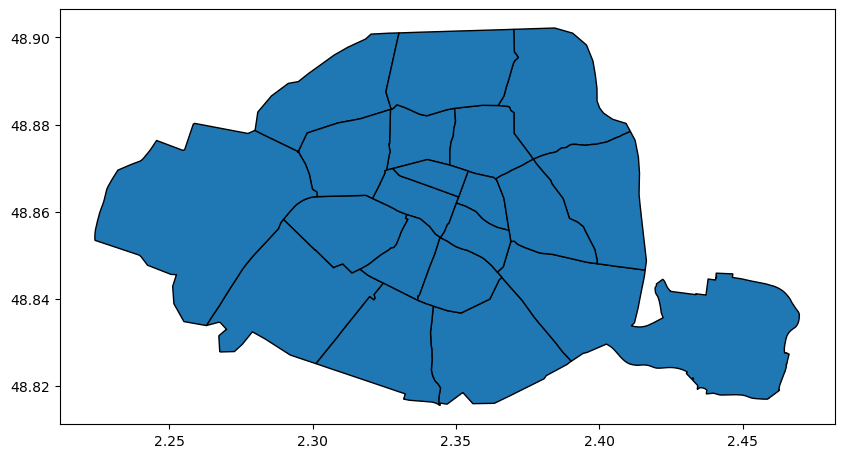

In [29]:
gdf_neigh.plot(figsize=(10, 10), edgecolor='black')

## 2. Affichage des logements sur la carte

#### Nous allons pour cela transformer notre dataframe listings en GeoDataframe

In [30]:
gdf_listings = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean.longitude, df_clean.latitude),
    crs="EPSG:4326" ) # système GPS

<Axes: >

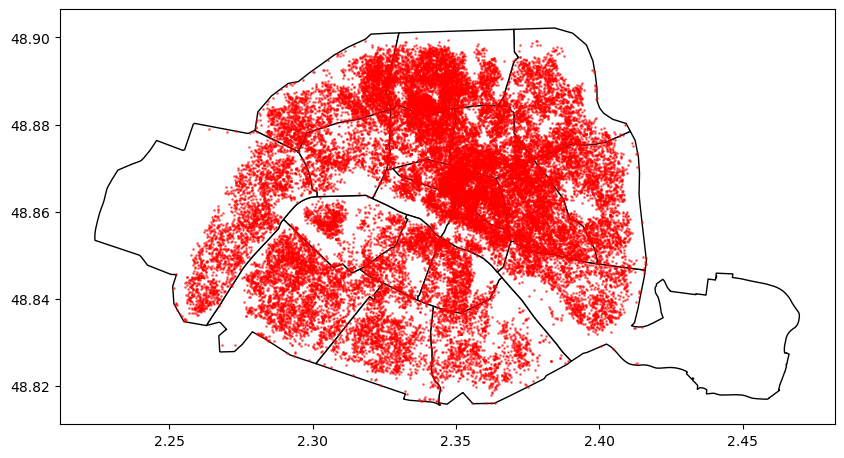

In [31]:
ax = gdf_neigh.plot(figsize=(10, 10), color="white", edgecolor="black")
gdf_listings.plot(ax=ax, markersize=1, color="red", alpha=0.5)

## 3. Récuperation de la Seine via OSM (OpenStreetMap) et ajout de la colonne distance

In [33]:
import osmnx as ox


# Définir les tags pour récupérer les cours d'eau (notamment la Seine)
tags = {"waterway": "river"}

# Télécharger les entités correspondant à ces tags à Paris
gdf = ox.features_from_place("Paris, France", tags=tags)

# Filtrer les entités dont le nom contient 'Seine'
seine = gdf[gdf['name'].str.contains("Seine", na=False)]

# Vérification
print(seine[['name', 'geometry']].head())

                                           name  \
element id                                        
way     32496111                       La Seine   
        99550443                       La Seine   
        99555151          La Seine - Bras Marie   
        99555152  La Seine - Bras de la Monnaie   
        99555154                       La Seine   

                                                           geometry  
element id                                                           
way     32496111  LINESTRING (2.40936 48.81663, 2.40762 48.8174,...  
        99550443  LINESTRING (2.23046 48.86786, 2.23093 48.86814...  
        99555151  LINESTRING (2.3614 48.84847, 2.36095 48.84931,...  
        99555152  LINESTRING (2.35386 48.85119, 2.35325 48.85125...  
        99555154  LINESTRING (2.28874 48.85721, 2.28834 48.85547...  


In [34]:
print("CRS gdf_neigh:", gdf_neigh.crs)
print("CRS seine:", seine.crs)
print("CRS gdf_listings:", gdf_listings.crs) # On vérifie que les trois geodataframe sont en coordonnées semblables gps

CRS gdf_neigh: EPSG:4326
CRS seine: epsg:4326
CRS gdf_listings: EPSG:4326


In [35]:
# Reprojection en Lambert 93 (EPSG:2154)
gdf_neigh_proj = gdf_neigh.to_crs(epsg=2154)
seine_proj = seine.to_crs(epsg=2154)
gdf_listings_proj = gdf_listings.to_crs(epsg=2154) # On passe en Lambert pour calculer les distances 

In [37]:
print("Bornes quartiers:", gdf_neigh_proj.total_bounds)
print("Bornes Seine:", seine_proj.total_bounds)
print("Bornes logements:", gdf_listings_proj.total_bounds) # On vérifie que les trois sont dans la même zone à peu près 

Bornes quartiers: [ 643065.72945475 6857478.61174764  661079.59645316 6867082.55627783]
Bornes Seine: [ 642959.80567831 6857558.49823922  656629.75470821 6867009.69615124]
Bornes logements: [ 645078.23300435 6857525.01367132  657162.5328598  6866857.46002579]


C:\Users\huvelle\AppData\Local\Temp\ipykernel_15100\3399299577.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


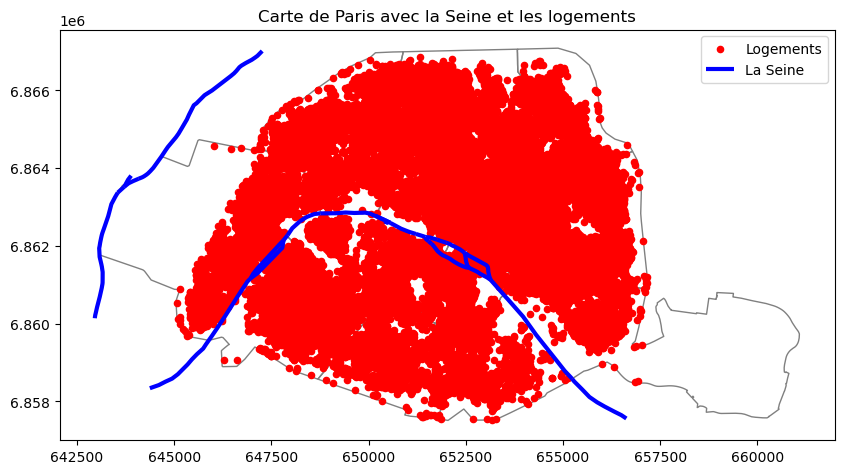

In [38]:
from shapely.ops import unary_union

seine_unie = unary_union(seine_proj.geometry)  # On a fait une réunion de tous les segments qui constituent la seine 

fig, ax = plt.subplots(figsize=(10,10))
gdf_neigh_proj.plot(ax=ax, facecolor='none', edgecolor='gray', label='Quartiers')
gdf_listings_proj.plot(ax=ax, color='red', markersize=20, label='Logements')
gpd.GeoSeries(seine_unie).plot(ax=ax, color='blue', linewidth=3, label='La Seine')

plt.legend()
plt.title("Carte de Paris avec la Seine et les logements")
plt.show()  

In [40]:
gdf_listings_proj['distance_seine'] = gdf_listings_proj.geometry.apply(lambda x: x.distance(seine_unie)) # Construction de la colonne
print(gdf_listings_proj[['distance_seine']].head()) 

   distance_seine
0        7.282508
2     1370.029031
4     1665.621759
6     5337.019100
8     1466.326794


In [41]:
gdf_listings_proj.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights,geometry,distance_seine
0,5396,Hôtel-de-Ville,48.85247,2.35835,Entire home/apt,88.0,77,425,2.26,3,POINT (652916.524 6861572.356),7.282508
2,9952,Popincourt,48.86238,2.36957,Entire home/apt,150.0,250,52,0.36,4,POINT (653748.614 6862667.632),1370.029031
4,12452,Popincourt,48.85974,2.37932,Entire home/apt,201.0,34,62,0.77,1,POINT (654461.599 6862368.418),1665.621759
6,17287,Buttes-Chaumont,48.89772,2.38508,Entire home/apt,82.0,234,48,0.39,4,POINT (654917.082 6866588.255),5337.019100
8,21004,Reuilly,48.83797,2.40058,Entire home/apt,200.0,324,129,0.72,2,POINT (656003.008 6859935.739),1466.326794


#### Supprimons la colonne 'geometry' et renommons proprement ce Dataset

In [42]:
df_enrichi = gdf_listings_proj.drop(columns='geometry')

In [43]:
df_enrichi.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights,distance_seine
0,5396,Hôtel-de-Ville,48.85247,2.35835,Entire home/apt,88.0,77,425,2.26,3,7.282508
2,9952,Popincourt,48.86238,2.36957,Entire home/apt,150.0,250,52,0.36,4,1370.029031
4,12452,Popincourt,48.85974,2.37932,Entire home/apt,201.0,34,62,0.77,1,1665.621759
6,17287,Buttes-Chaumont,48.89772,2.38508,Entire home/apt,82.0,234,48,0.39,4,5337.019100
8,21004,Reuilly,48.83797,2.40058,Entire home/apt,200.0,324,129,0.72,2,1466.326794


# Partie3: Ajout du prix moyen journalier via calendar (dec 2024) 

## 1. Importation du fichier calendar

In [44]:
calendar = pd.read_csv("DATA_dec_2024/calendar_dec_2024.csv.gz", compression='gzip',low_memory=False)

In [45]:
calendar.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,3109,2024-12-07,f,$100.00,NaN,2.0,30.0
1,3109,2024-12-08,t,$100.00,NaN,2.0,30.0
2,3109,2024-12-09,f,$100.00,NaN,2.0,30.0
3,3109,2024-12-10,f,$100.00,NaN,2.0,30.0
4,3109,2024-12-11,f,$100.00,NaN,2.0,30.0


In [46]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33226170 entries, 0 to 33226169
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           object 
 4   adjusted_price  object 
 5   minimum_nights  float64
 6   maximum_nights  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 1.7+ GB


In [47]:
calendar.sample(15)

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
21005576,984704764932294459,2025-04-23,f,$199.00,NaN,1.0,99.0
6748819,24512833,2025-10-19,f,$450.00,NaN,3.0,1125.0
12615758,52591258,2025-07-29,t,$850.00,NaN,5.0,1125.0
14494225,658445596517704446,2025-01-15,f,$280.00,NaN,2.0,1125.0
1058184,3364859,2025-01-21,f,$120.00,NaN,365.0,1125.0
13856974,622151321831976466,2025-02-25,f,$350.00,NaN,4.0,365.0
32131643,1256979202258637305,2024-12-24,t,$170.00,NaN,2.0,25.0
20226182,958001232617743593,2024-12-27,t,"$1,000.00",NaN,3.0,365.0
1797570,5922355,2025-10-06,f,$70.00,NaN,365.0,1125.0
16432835,800590878137844947,2025-04-16,f,$120.00,NaN,2.0,1125.0


In [48]:
calendar.isnull().sum() #sommes des valeurs manquantes par colonne

listing_id               0
date                     0
available                0
price                    0
adjusted_price    33203905
minimum_nights         397
maximum_nights         397
dtype: int64

## 2.Nettoyage du fichier et filtrages

In [49]:
# convertion de la date en datetime
calendar['date'] = pd.to_datetime(calendar['date'])

In [50]:
# Filtrer sur mars 2025 uniquement
calendar = calendar[
    (calendar['date'].dt.month == 3) & 
    (calendar['date'].dt.year == 2025)
] 

In [51]:
# Filtrer les logements disponibles
calendar_dispo = calendar[calendar['available'] == 't'].copy()

In [52]:
# Nettoyons la colonne price
calendar_dispo['price'] = calendar_dispo['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
calendar_dispo['price'] = calendar_dispo['price'].replace('nan', np.nan).astype(float)
calendar_dispo = calendar_dispo[calendar_dispo['price'] > 0]

In [53]:
# Filtrons et gardons les prix inférieurs à 500€
calendar_dispo = calendar_dispo[
    (calendar_dispo['price'] <= 500)
]

In [54]:
# Supprimer colonnes inutiles
calendar_dispo = calendar_dispo.drop(columns=['adjusted_price', 'minimum_nights', 'maximum_nights', 'available'])

## 3. Calculer prix moyen journalier par logement

In [55]:
prix_moyen = calendar_dispo.groupby('listing_id')['price'].mean().reset_index()
prix_moyen.rename(columns={'price': 'prix_moyen_journalier'}, inplace=True)

## 4. Fusion avec le dataframe listings enrichi (avec distance à la Seine, quartier...)

In [56]:
df_final = df_enrichi.merge(prix_moyen, left_on='id', right_on='listing_id', how='left') # Jointure "à gauche"

In [57]:
df_final.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights,distance_seine,listing_id,prix_moyen_journalier
0,5396,Hôtel-de-Ville,48.85247,2.35835,Entire home/apt,88.0,77,425,2.26,3,7.282508,5396.0,125.0
1,9952,Popincourt,48.86238,2.36957,Entire home/apt,150.0,250,52,0.36,4,1370.029031,9952.0,80.0
2,12452,Popincourt,48.85974,2.37932,Entire home/apt,201.0,34,62,0.77,1,1665.621759,NaN,NaN
3,17287,Buttes-Chaumont,48.89772,2.38508,Entire home/apt,82.0,234,48,0.39,4,5337.019100,17287.0,82.0
4,21004,Reuilly,48.83797,2.40058,Entire home/apt,200.0,324,129,0.72,2,1466.326794,21004.0,200.0


In [58]:
# Nettoyons df_final en supprimant colonnes inutiles 
df_final.drop(columns=['listing_id', 'price', 'room_type'], inplace=True )

In [59]:
# vérification
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40840 entries, 0 to 40839
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     40840 non-null  int64  
 1   neighbourhood          40840 non-null  object 
 2   latitude               40840 non-null  float64
 3   longitude              40840 non-null  float64
 4   availability_365       40840 non-null  int64  
 5   number_of_reviews      40840 non-null  int64  
 6   reviews_per_month      33228 non-null  float64
 7   minimum_nights         40840 non-null  int64  
 8   distance_seine         40840 non-null  float64
 9   prix_moyen_journalier  29346 non-null  float64
dtypes: float64(5), int64(4), object(1)
memory usage: 3.1+ MB


#### Le fait qu'on ai 10089 logements sans prix moyen est normal vu les conditions :
#### On travailles uniquement sur dec 2024
#### On ne prends que les logements disponibles
#### Donc si un logement n’est pas dispo en sept, ou qu’il n’a pas de prix renseigné à ces dates → pas de prix moyen.

In [60]:
df_final = df_final[df_final['prix_moyen_journalier'].notna()]

In [61]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29346 entries, 0 to 40839
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     29346 non-null  int64  
 1   neighbourhood          29346 non-null  object 
 2   latitude               29346 non-null  float64
 3   longitude              29346 non-null  float64
 4   availability_365       29346 non-null  int64  
 5   number_of_reviews      29346 non-null  int64  
 6   reviews_per_month      23066 non-null  float64
 7   minimum_nights         29346 non-null  int64  
 8   distance_seine         29346 non-null  float64
 9   prix_moyen_journalier  29346 non-null  float64
dtypes: float64(5), int64(4), object(1)
memory usage: 2.5+ MB


#### Enfin, ajoutons une colonne 'période' pour ajouter une variable temporelle à notre projet

In [62]:
df_final['periode'] = 'dec_2024'

In [63]:
df_final_dec2024=df_final.copy()

In [64]:
df_final_dec2024.to_csv("../OUTPUT/listings_dec2024_clean.csv", index=False)